In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import scipy.sparse as sp
import time
import gget
from scipy.stats import spearmanr
from scipy.stats import pearsonr
from scipy.stats import ttest_ind
from tqdm import tqdm
import textwrap

import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scvi

from scvi.external import CellAssign

import cupy as cp
import cuml

sc.settings.verbosity = 3

/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


# Load anndata

In [2]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/pseudotime.h5ad"
adata = sc.read_h5ad(fpath)
adata

CPU times: user 310 ms, sys: 2.33 s, total: 2.64 s
Wall time: 11.1 s


AnnData object with n_obs × n_vars = 15867 × 21412
    obs: 'batch', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'n_reads', 'raw_clusters', 'bbknn_clusters', 'harmony_clusters', 'cluster_str', 'barcoded_phase', 'S_score', 'G2M_score', 'dpt_pseudotime', 'dpt_groups', 'dpt_order', 'dpt_order_indices', 'G1_pseudotime', 'G1_order', 'G2M_pseudotime', 'G2M_order', 'mean_pseudotime', 'mean_order', 'nnz'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersio

# Load Capybara scores

In [3]:
%%time
# Load Capybara output
# fpath_scale = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/capybara/capybara_basename_scale.csv"
# fpath_scale = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/capybara/basename_simple_scale.csv"
# fpath_scale = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/capybara/gomes_scale.csv"
# fpath_scale = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/capybara/celltype_simplified_scale.csv"
fpath_scale = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/capybara/celltype_simplified_scale.csv"
df = pd.read_csv(fpath_scale)
print(f"{df.shape=}")
df.head()

df.shape=(15867, 18)
CPU times: user 36.6 ms, sys: 8.27 ms, total: 44.9 ms
Wall time: 46.6 ms


,cell_name,frxn_blood vessel endothelial cell,frxn_embryonic fibroblast,frxn_endothelial cell,frxn_endothelial cell of vascular tree,frxn_erythroid progenitor cell,frxn_fibro/adipogenic progenitor cell,frxn_fibroblast,frxn_hematopoietic multipotent progenitor cell,frxn_hematopoietic precursor cell,frxn_hematopoietic stem cell,frxn_megakaryocyte progenitor cell,frxn_retinal blood vessel endothelial cell,frxn_skeletal muscle fibroblast,frxn_skin fibroblast,frxn_vein endothelial cell,Lagrangian,Error
0,AAACCCAAGGTTACCT-1,2.655916e-02,0.216079,0.091959,6.328028e-19,0.173432,0.212594,-3.560497e-17,4.130600e-18,5.345941e-02,1.141456e-02,-1.043146e-18,1.772187e-02,0.000000e+00,0.108831,-6.786521e-20,0,2313.197846
1,AAACCCAAGTTGAAGT-1,2.168404e-19,0.165552,0.068983,6.479794e-19,0.195067,0.307927,2.772110e-19,1.072217e-17,3.286334e-02,1.172854e-19,1.588551e-19,9.481993e-02,3.919296e-19,0.039850,-4.063729e-18,0,2383.611270
2,AAACCCAAGTTGTCGT-1,4.254147e-02,0.289692,0.004696,-7.821219e-20,0.265483,0.141732,1.078867e-17,4.761845e-17,0.000000e+00,7.760973e-19,-1.391568e-17,-1.204080e-17,7.148037e-19,0.103968,1.489369e-17,0,2356.420129
3,AAACCCACAGAAGCGT-1,0.000000e+00,0.243536,0.019734,3.229160e-19,0.108869,0.193898,2.272758e-18,4.835065e-18,4.834411e-02,-4.798990e-19,1.285999e-17,5.416928e-02,2.509075e-21,0.198415,9.908375e-17,0,2402.670451
4,AAACCCACAGGAGGTT-1,3.103968e-02,0.218691,0.163875,1.206910e-17,0.187455,0.130098,1.171735e-17,-8.434668e-18,-2.110209e-17,1.107051e-18,-2.003732e-17,4.612713e-02,6.938894e-18,0.099957,2.334821e-17,0,2134.605059


In [4]:
list(df.columns)

['cell_name',
 'frxn_blood vessel endothelial cell',
 'frxn_embryonic fibroblast',
 'frxn_endothelial cell',
 'frxn_endothelial cell of vascular tree',
 'frxn_erythroid progenitor cell',
 'frxn_fibro/adipogenic progenitor cell',
 'frxn_fibroblast',
 'frxn_hematopoietic multipotent progenitor cell',
 'frxn_hematopoietic precursor cell',
 'frxn_hematopoietic stem cell',
 'frxn_megakaryocyte progenitor cell',
 'frxn_retinal blood vessel endothelial cell',
 'frxn_skeletal muscle fibroblast',
 'frxn_skin fibroblast',
 'frxn_vein endothelial cell',
 'Lagrangian',
 'Error']

In [5]:
# Set index to 'cell_name' for merging
df = df.set_index('cell_name')

# Sanity check: ensure all indices in df exist in adata.obs
common_cells = adata.obs.index.intersection(df.index)
print(f"Merging on {len(common_cells)} shared cells")

# Merge into adata.obs
adata.obs = adata.obs.join(df, how='left')  # 'left' keeps all cells in adata.obs

adata.obs.head()

Merging on 15867 shared cells


,batch,phase,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,...,frxn_hematopoietic multipotent progenitor cell,frxn_hematopoietic precursor cell,frxn_hematopoietic stem cell,frxn_megakaryocyte progenitor cell,frxn_retinal blood vessel endothelial cell,frxn_skeletal muscle fibroblast,frxn_skin fibroblast,frxn_vein endothelial cell,Lagrangian,Error
AAACCCAAGGTTACCT-1,hsc,G1,3679,8.210668,11202.0,9.323937,27.932512,37.752187,47.491519,60.382075,...,4.130600e-18,5.345941e-02,1.141456e-02,-1.043146e-18,1.772187e-02,0.000000e+00,0.108831,-6.786521e-20,0,2313.197846
AAACCCAAGTTGAAGT-1,hsc,G1,3987,8.291045,10579.0,9.266721,24.766046,32.867001,40.835618,53.313168,...,1.072217e-17,3.286334e-02,1.172854e-19,1.588551e-19,9.481993e-02,3.919296e-19,0.039850,-4.063729e-18,0,2383.611270
AAACCCAAGTTGTCGT-1,hsc,S,2585,7.857868,6735.0,8.815222,28.537491,37.371938,48.136600,63.533779,...,4.761845e-17,0.000000e+00,7.760973e-19,-1.391568e-17,-1.204080e-17,7.148037e-19,0.103968,1.489369e-17,0,2356.420129
AAACCCACAGAAGCGT-1,hsc,G1,2358,7.765993,5416.0,8.597297,24.686115,34.785820,45.217873,60.672083,...,4.835065e-18,4.834411e-02,-4.798990e-19,1.285999e-17,5.416928e-02,2.509075e-21,0.198415,9.908375e-17,0,2402.670451
AAACCCACAGGAGGTT-1,hsc,G1,4997,8.516793,21937.0,9.995976,31.845740,40.552491,50.152710,63.440762,...,-8.434668e-18,-2.110209e-17,1.107051e-18,-2.003732e-17,4.612713e-02,6.938894e-18,0.099957,2.334821e-17,0,2134.605059


### frxn_cols = [col for col in df.columns if col.startswith("frxn_")]
frxn_cols

['vein endothelial cell' 'skin fibroblast' 'skeletal muscle fibroblast'
 'retinal blood vessel endothelial cell' 'megakaryocyte progenitor cell'
 'hematopoietic stem cell' 'hematopoietic precursor cell'
 'hematopoietic multipotent progenitor cell' 'fibroblast'
 'fibro/adipogenic progenitor cell' 'erythroid progenitor cell'
 'endothelial cell of vascular tree' 'endothelial cell'
 'embryonic fibroblast' 'blood vessel endothelial cell']


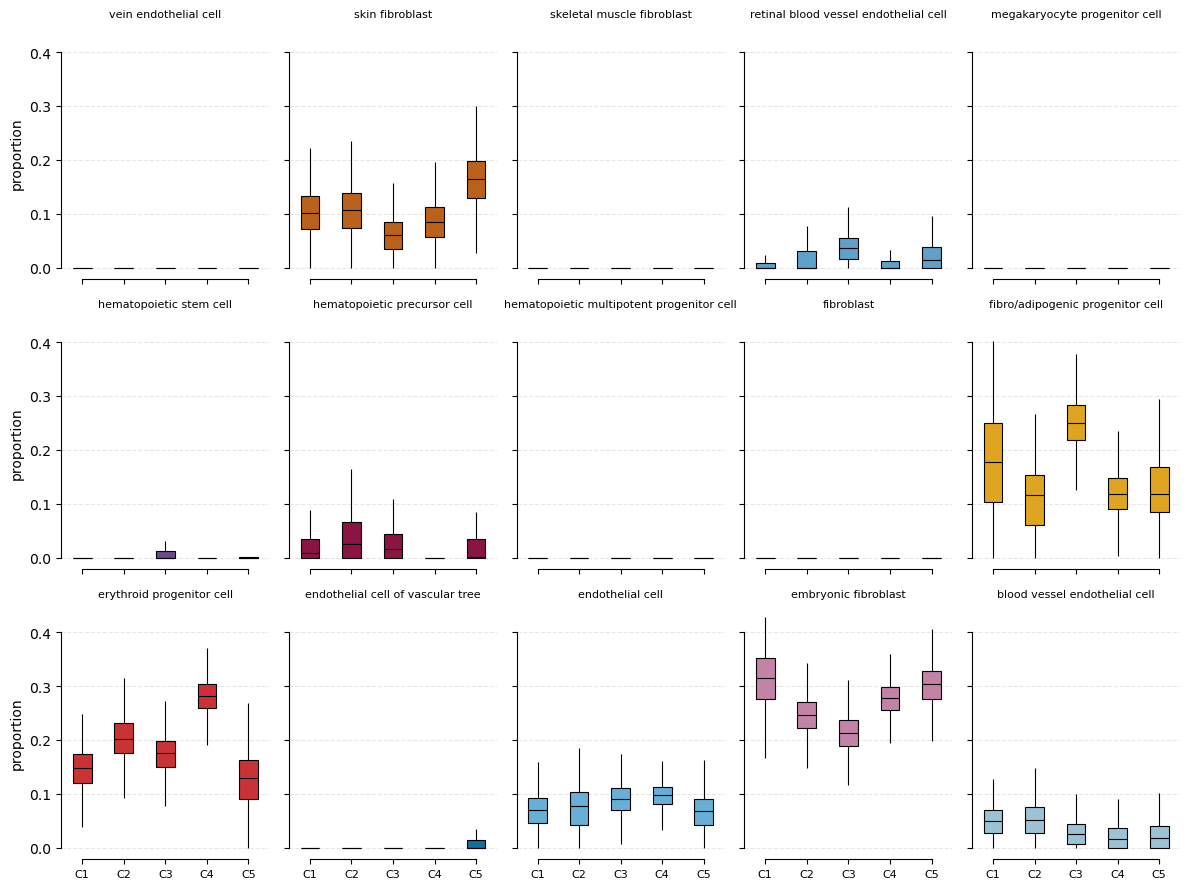

In [6]:
# Copy and melt
df = adata.obs.copy()
frxn_cols = [col for col in df.columns if col.startswith("frxn_")]
df_melted = df.melt(
    id_vars=["cluster_str"],
    value_vars=frxn_cols,
    var_name="Cell Type",
    value_name="Fraction"
)

df_melted['Cell Type'] = df_melted['Cell Type'].str.replace('frxn_', '')
df_melted = df_melted.sort_values('Cell Type', ascending=False)

print(df_melted['Cell Type'].unique())

palette = {
    # Fibroblast lineage – warm earth tones
    'fibroblast': '#E69F00',                        # orange
    'skin fibroblast': '#D55E00',                   # rust
    'skeletal muscle fibroblast': '#F0E442',        # yellow
    'embryonic fibroblast': '#CC79A7',              # soft pink
    'fibro/adipogenic progenitor cell': '#FFB000',  # gold

    # Endothelial lineage – cool blues
    'endothelial cell': '#56B4E9',                          # sky blue
    'endothelial cell of vascular tree': '#0072B2',         # strong blue
    'blood vessel endothelial cell': '#92C5DE',             # light blue
    'retinal blood vessel endothelial cell': '#4EA5D9',      # mid blue
    'vein endothelial cell': '#08306B',                     # dark navy

    # Hematopoietic lineage – purples and reds
    'hematopoietic stem cell': '#6A3D9A',                    # deep violet
    'hematopoietic precursor cell': '#9E0142',               # red-purple
    'hematopoietic multipotent progenitor cell': '#B35806',  # burnt orange
    'megakaryocyte progenitor cell': '#8E063B',              # wine red
    'erythroid progenitor cell': '#E31A1C'                   # red
}

# Plot with FacetGrid
g = sns.FacetGrid(
    df_melted,
    col="Cell Type",
    col_wrap=5,
    sharey=True,
    height=3,
    aspect=0.8,
)

g.map_dataframe(
    sns.boxplot,
    x="cluster_str",
    y="Fraction",
    hue='Cell Type',
    order=sorted(df["cluster_str"].unique()),
    width=0.45,
    linecolor='k',
    palette=palette,
    capprops={'linewidth': 0},  
    showfliers=False,
    linewidth=0.8
)

g.set_axis_labels("", "proportion")
g.set_titles(col_template="{col_name}", size=8)
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=0, labelsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

g.fig.subplots_adjust(wspace=0.2)

plt.tight_layout()
sns.despine(trim=True)
plt.show()


In [7]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
frxn_cols = [col for col in adata.obs.columns if col.startswith("frxn_")]
adata.obs['predcition'] = adata.obs[frxn_cols].idxmax(axis=1)
adata.obs['predcition'] = adata.obs['predcition'].str.replace('frxn_', '')

print(adata.obs['predcition'].value_counts().to_string())


plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.draw_graph(
    adata, 
    color=['predcition'],
    size=10,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    na_in_legend=False,
    palette=palette,
    title="",
    frameon=False,
    wspace=0.15,
    show=False, 
)


# Hybrid assignments

In [ ]:
# Assign based on max fraction
frac_cols = [x for x in adata.obs.columns if 'frxn_' in x]
print(frac_cols)

# Relaxed threshold for hybrid assignment
hybrid_thresh = 0.2

def assign_relaxed_hybrid(row):
    # Get fractions above threshold
    above_thresh = row[row > hybrid_thresh].index.tolist()
    
    # Clean and format label
    if len(above_thresh) == 0:
        return "unassigned"
    
    clean_labels = [s.replace("frxn_", "").replace("_", " ") for s in above_thresh]
    return "+".join(sorted(clean_labels))

# Apply to obs
adata.obs['capybara_assignment'] = adata.obs[frac_cols].apply(assign_relaxed_hybrid, axis=1)

print(adata.obs['capybara_assignment'].value_counts().to_string())
print()

# Group and count
plot_df = (
    adata.obs
    .groupby(['cluster_str', 'capybara_assignment'])
    .size()
    .reset_index(name='count')
)

# Clean labels
plot_df['capybara_assignment'] = (
    plot_df['capybara_assignment']
    .str.replace("frxn_", "", regex=False)
    .str.replace("_", " ")
)

# Normalize to proportions within each cluster
plot_df['proportion'] = (
    plot_df
    .groupby('cluster_str')['count']
    .transform(lambda x: x / x.sum())
)
plot_df.head()

In [ ]:
# Pivot to wide format: rows = assignment, columns = cluster, values = proportion
heat_df = plot_df.pivot(
    index='capybara_assignment',
    columns='cluster_str',
    values='proportion'
).fillna(0)


# Define abbreviations
abbrev_map = {
    'fibroblasts': 'Fib',
    'hematopoietic progenitors': 'HP',
    'endothelial cells': 'EC',
    'hsc': 'HSC',
    'unassigned': 'NA'
}

# Helper to rename full label to abbreviations and replace "+" with "/"
def abbreviate(label):
    parts = label.split('+')
    abbrev_parts = [abbrev_map.get(p.strip(), p.strip()) for p in parts]
    return '/'.join(abbrev_parts)

# Apply to index
heat_df.index = heat_df.index.map(abbreviate)


plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4.75, 10

sns.heatmap(
    heat_df,
    cmap='plasma',
    linewidths=0.5,
    square=True,
    linecolor='gray',
    cbar_kws={'label': 'proportion of cells', 'shrink': 0.5},
    annot=True,
    fmt=".2f"
)

plt.xlabel("")
plt.ylabel("hybrid assignments")
plt.tight_layout()
plt.show()


# Find the correlates

In [ ]:
# Extract gene expression matrix (assumes log-normalized)
X = adata.X
if not isinstance(X, np.ndarray):
    X = X.toarray()  # Convert sparse matrix to dense if needed

# Get gene names
gene_names = adata.var_names

# Extract cell-level fractions
obs_df = adata.obs[frxn_cols].copy()
assert obs_df.shape[0] == X.shape[0], "Mismatch in number of cells"

# Store results
results = []

print("Computing Spearman correlations...")
for frxn_col in tqdm(frxn_cols):
    for i, gene in enumerate(gene_names):
        rho, pval = spearmanr(X[:, i], obs_df[frxn_col])
        results.append({
            'Fraction Type': frxn_col,
            'Gene': gene,
            'SpearmanR': rho,
            'P-value': pval
        })

# Convert to DataFrame
cor_df = pd.DataFrame(results)

print('done!')


In [ ]:
# For each fraction type, get top genes by absolute Spearman R
alpha = 0.05
pdf = cor_df[cor_df['P-value'] < alpha].copy()
pdf = pdf.sort_values(['Fraction Type', 'SpearmanR'], ascending=[True, False])
pdf = pdf[~pdf['Gene'].str.startswith('RP')]


# For each fraction type, get top genes by absolute Spearman R
top_cor_df = pdf.groupby('Fraction Type', group_keys=False).head(15)
print(top_cor_df.to_string(index=False))

# Enrichment

In [ ]:
# For each fraction type, get top genes by absolute Spearman R
alpha = 0.05
pdf = cor_df[cor_df['P-value'] < alpha].copy()
pdf = pdf.sort_values(['Fraction Type', 'SpearmanR'], ascending=[True, False])
pdf = pdf[~pdf['Gene'].str.startswith('RP')]

# For each fraction type, get top genes by absolute Spearman R
top_cor_df = pdf.groupby('Fraction Type', group_keys=False).head(15)

top_cor_df.head()

In [ ]:
# Filter significant correlations
alpha = 0.05
pdf = cor_df[cor_df['P-value'] < alpha].copy()
pdf = pdf.sort_values(['Fraction Type', 'SpearmanR'], ascending=[True, False])
pdf = pdf[~pdf['Gene'].str.startswith('RP')]

# Get top 15 genes by Fraction Type
top_cor_df = pdf.groupby('Fraction Type', group_keys=False).head(15)

for frac_type, group in top_cor_df.groupby('Fraction Type'):
    genes = group['Gene'].head(100).tolist()
    edf = gget.enrichr(genes, database="ontology")
    edf['genes'] = edf['overlapping_genes'].apply(lambda x: ",".join(x))
    edf = edf[['path_name', 'adj_p_val', 'genes']]
    print("=" * 20, f"{frac_type}", "=" * 20)
    print(edf.head(10).to_string(index=False))

    edf['log_adj_p'] = -np.log10(edf['adj_p_val'].clip(lower=1e-300))
    edf['path_name_wrapped'] = edf['path_name'].apply(lambda x: '\n'.join(textwrap.wrap(x, width=60)))

    # Barplot
    plt.rcParams['figure.dpi'] = 300
    plt.rcParams['figure.figsize'] = 4, 4
    sns.barplot(
        data=edf.head(15),
        y='path_name_wrapped',
        x='log_adj_p',
        ec='k',
        color='lightgrey',
        linewidth=0.75,
        width=0.5,
    )
    plt.xlabel('-log10(Adjusted P-value)')
    plt.ylabel('')
    plt.yticks(fontsize=6)
    plt.title(frac_type)
    sns.despine(trim=True)
    plt.show()

# Plotting

In [ ]:
pdf = cor_df[cor_df['P-value'] < alpha].copy()
pdf[pdf['Fraction Type'] == 'frxn_endothelial_cells'].sort_values('SpearmanR', ascending=False).head(25)

In [ ]:

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

color = [
    'SERPINE1', 'HIP1', 'AHNAK2',
    'MAGI2', 'GAS7', 'YWHAZ',
]

sc.pl.draw_graph(
    adata, 
    color=color,
    size=25,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.15,
)


In [ ]:
# For each fraction type, get top genes by absolute Spearman R
alpha = 0.05
pdf = cor_df[cor_df['P-value'] < alpha].copy()
pdf = pdf.sort_values(['Fraction Type', 'SpearmanR'], ascending=[True, False])
pdf = pdf[~pdf['Gene'].str.startswith('RP')]


labels = {
    'frxn_endothelial_cells': 'Endothelial Cells',
    'frxn_fibroblasts': 'Fibroblasts',
    'frxn_hematopoietic_progenitors': 'Progenitors',
    'frxn_hsc': 'HSCs'
}


# For each fraction type, get top genes by absolute Spearman R
top_cor_df = pdf.groupby('Fraction Type', group_keys=False).head(15)
top_cor_df['label'] = top_cor_df['Fraction Type'].map(labels)

for group, group_df in top_cor_df.groupby(['label']):

    frxn_type = group_df['Fraction Type'].unique()[0]
    plt.rcParams['figure.dpi'] = 300
    plt.rcParams['figure.figsize'] = 4, 4

    sc.pl.draw_graph(
        adata, 
        color=[frxn_type] + group_df['Gene'].head(8).to_list(),
        size=25,
        ncols=3,
        alpha=1,
        use_raw=False,
        add_outline=True,
        outline_color=('k', 'k'),
        title=[group[0]] + group_df['Gene'].head(8).to_list(),
        frameon=False,
        wspace=0.15,
        show=False, 
    )

    plt.suptitle(f"{group[0]} correlates", fontsize=14)
    plt.show()    